###**1. Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

### **2. Loading the dataset**

In [ ]:
amazon = pd.read_csv("/content/amazon_ecommerce_1M.csv")

/tmp/ipykernel_2821/461551238.py:1: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  amazon = pd.read_csv("/content/amazon_ecommerce_1M.csv")


### **3. Inspecting the Dataset**

In [ ]:
#Display the first 5 rows
amazon.head(5)

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,...,location,device,payment_method,is_returned,delivery_status,Revenue,month,year,returned,revenue
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,...,Bangalore,Tablet,UPI,True,Returned,29629.31,3,2025,NaN,29629.31
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,...,Delhi,Tablet,UPI,True,Returned,8870.73,12,2025,NaN,8870.73
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,...,Chennai,Mobile App,Credit Card,True,Returned,10919.43,4,2024,NaN,10919.43
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,...,Mumbai,Web,UPI,False,In Transit,502.91,12,2025,NaN,502.91
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,...,Delhi,Web,UPI,False,Delayed,5589.58,5,2024,NaN,5589.58


In [ ]:
#Understanding dataset dimensions
amazon.shape

(1000000, 20)

The dataset has 1M rows and 20 columns

In [ ]:
#Summary of the dataset
amazon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1000000 non-null  object 
 1   product_id          1000000 non-null  object 
 2   category            1000000 non-null  object 
 3   subcategory         1000000 non-null  object 
 4   brand               1000000 non-null  object 
 5   price               1000000 non-null  float64
 6   discount            1000000 non-null  float64
 7   final_price         1000000 non-null  float64
 8   rating              1000000 non-null  float64
 9   review_count        1000000 non-null  int64  
 10  stock               1000000 non-null  int64  
 11  seller_id           1000000 non-null  object 
 12  seller_rating       1000000 non-null  float64
 13  purchase_date       1000000 non-null  object 
 14  shipping_time_days  1000000 non-null  int64  
 15  location        

The dataset has no null values

In [ ]:
#Listing the column names
amazon.columns

Index(['user_id', 'product_id', 'category', 'subcategory', 'brand', 'price',
       'discount', 'final_price', 'rating', 'review_count', 'stock',
       'seller_id', 'seller_rating', 'purchase_date', 'shipping_time_days',
       'location', 'device', 'payment_method', 'is_returned',
       'delivery_status', 'Revenue', 'month', 'year', 'returned', 'revenue'],
      dtype='object')

In [ ]:
#Descriptive statistics
amazon.describe()

,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,13224.119093,28.996161,9938.876985,3.927226,32.626704,250.023345,3.750030,3.166389
std,18079.626921,14.681077,14271.885557,0.519443,43.382201,144.567038,0.722092,1.674178
min,200.030000,5.000000,101.460000,1.500000,0.000000,0.000000,2.500000,1.000000
25%,2700.147500,16.910000,1705.930000,3.600000,10.000000,125.000000,3.100000,2.000000
50%,4971.830000,28.070000,3790.795000,3.900000,20.000000,250.000000,3.800000,3.000000
75%,14134.482500,39.240000,10384.440000,4.300000,39.000000,375.000000,4.400000,5.000000
max,79999.700000,70.000000,75831.110000,5.000000,3408.000000,500.000000,5.000000,6.000000


In [ ]:
#Counting the missing values
amazon.isnull().sum()

,0
user_id,0
product_id,0
category,0
subcategory,0
brand,0
price,0
discount,0
final_price,0
rating,0
review_count,0


There are no missing values in the columns

In [ ]:
#Indentifying duplicate rows
amazon.duplicated().sum()

np.int64(0)

No duplicates in the dataset

### **Data Cleaning**

In [ ]:
#Changing the datatype of  purchase date column
amazon['purchase_date'] = pd.to_datetime(amazon['purchase_date'])


### **Feature engineering**

In [ ]:
#1. Revenue
amazon['revenue'] = amazon['final_price']

In [ ]:
#2. Deriving month and year from date
amazon['month'] = amazon['purchase_date'].dt.month
amazon['year']= amazon['purchase_date'].dt.year

In [ ]:
#3.return
amazon['returned'] = amazon['is_returned'].map({True:1,False:0})

### **Exploratory Data Analysis**

In [ ]:
#1.Which product categories generate the most revenue?
amazon.groupby('category')['revenue'].sum().sort_values(ascending=False)

,revenue
category,
Electronics,2.011507e+09
Home,4.716283e+08
Sports,3.474452e+08
Beauty,1.153897e+08
Clothing,1.007444e+08


Electronics overwhelmingly drives the platform's financial performance by generating over 2.01 billion dollars, more than triple the second-highest category, Home ($471.6 million), revealing that the company's core growth strategy must prioritize optimization and scaling of this single, high-leverage category.

In [ ]:
#2.Which brands contribute the most revenue?
amazon.groupby('brand')['revenue'].sum().sort_values(ascending=False)

,revenue
brand,
Boat,2.570729e+08
H&M,2.562255e+08
HP,2.559545e+08
Adidas,2.545598e+08
Lenovo,2.541889e+08
Puma,2.540826e+08
Apple,2.539338e+08
LG,2.532728e+08
Samsung,2.530166e+08


While Boat, H&M, and HP technically lead revenue contributions at approximately $257 million each, the critically narrow 2.8% variance across all twelve major brands indicates a highly distributed, fragmented market share where no single brand dominates the platform.

In [ ]:
#3.Which categories have the highest return rates?
amazon.groupby('category')['returned'].mean()*100

,returned
category,
Beauty,11.779908
Clothing,11.767594
Electronics,11.363488
Home,11.673749
Sports,11.800293


Sports, Beauty, and Clothing experience the highest percentage of customer returns, but because every category sits almost identically at around 11.8%. Customers return about 12 out of every 100 items no matter what category they shop in, meaning the company is losing profit to website-wide issues like misleading descriptions or delivery delays rather than problems with individual products

In [ ]:
#4. Do discounts increase sales or simply increase returns?
amazon.groupby('discount')['revenue'].mean()

,revenue
discount,
5.00,13415.153462
5.01,19033.942105
5.02,15426.360732
5.03,21079.399394
5.04,12443.674384
...,...
69.96,874.560000
69.97,828.157692
69.98,976.704000


In [ ]:
amazon.groupby('discount')['returned'].mean()*100

,returned
discount,
5.00,19.230769
5.01,18.421053
5.02,14.634146
5.03,12.121212
5.04,5.479452
...,...
69.96,0.000000
69.97,15.384615
69.98,0.000000


Huge discounts do not boost performance, as discounts increase from 5% up to 70%, the revenue drops drastically from around $13,000–$19,000 down to less than $800, meaning aggressive price cuts are severely hurting your profits rather than driving more sales.

In [ ]:
#5.Do delivery delays increase product returns?
amazon.groupby('shipping_time_days')['returned'].mean()*100

,returned
shipping_time_days,
1,10.758365
2,10.689917
3,10.613161
4,10.662265
5,10.540945
6,20.936594


Delivery delays drastically increase product returns, as the data shows that returns remain stable at around 10.6% for standard 1-to-5 day shipments, but skyrocket to nearly double (20.9%) the moment a delivery takes 6 days or longer

In [ ]:
#6.What factors are most strongly related to business performance?
numeric_cols = [
    'price',
    'discount',
    'final_price',
    'rating',
    'review_count',
    'stock',
    'seller_rating',
    'shipping_time_days'
]

amazon[numeric_cols].corr()

,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days
price,1.000000,-0.208509,0.986306,3.312825e-01,0.000259,-2.903712e-05,-0.002199,-0.000307
discount,-0.208509,1.000000,-0.291042,-7.169974e-02,0.001518,-2.336312e-03,0.002449,-0.001396
final_price,0.986306,-0.291042,1.000000,3.268088e-01,0.000219,-1.394218e-04,-0.002265,0.000233
rating,0.331283,-0.071700,0.326809,1.000000e+00,-0.001206,-2.543831e-07,-0.000643,0.000032
review_count,0.000259,0.001518,0.000219,-1.205784e-03,1.000000,-6.104014e-04,-0.001287,0.001072
stock,-0.000029,-0.002336,-0.000139,-2.543831e-07,-0.000610,1.000000e+00,-0.002109,-0.002650
seller_rating,-0.002199,0.002449,-0.002265,-6.427740e-04,-0.001287,-2.109430e-03,1.000000,0.004138
shipping_time_days,-0.000307,-0.001396,0.000233,3.232168e-05,0.001072,-2.649973e-03,0.004138,1.000000


Product price is the strongest factor driving business performance, showing an almost perfect positive link to final_price (0.98) and a strong positive link to rating (0.33), meaning higher-priced items actually pull in better customer reviews and higher total revenue.

Conversely, discounts are the biggest negative factor, showing a clear negative link to both final price (-0.29) and ratings (-0.07), which proves that heavy price cuts are actively lowering profit margins and hurting customer satisfaction.

### **Data Analysis**

In [ ]:
#1. What is the Total Revenue Generated?
Total_revenue = amazon['revenue'].sum()
print(f"Total Revenue: ${Total_revenue:,.2f}")

Total Revenue: $3,046,714,749.87


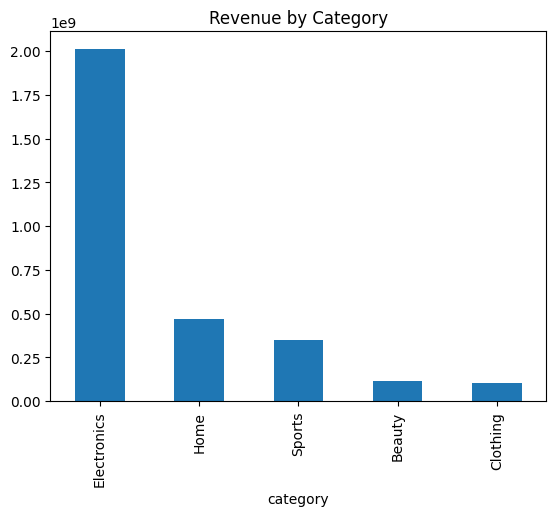

In [ ]:
#2. Which Categories Generate the Highest Revenue?
category = amazon.groupby('category')['revenue'].sum().sort_values(ascending=False)
category.plot(kind='bar')
plt.title('Revenue by Category')
plt.show()

Electronics generates the highest revenue by a massive margin, bringing in over 2.0 billion dollars.This completely dominates the other categories, making more than quadruple the second-highest category, Home (around $471 million), followed by Sports, Beauty, and Clothing.

In [ ]:
#3. Which Brands Generate the Highest Revenue?
brand = amazon.groupby('brand')['revenue'].sum().sort_values(ascending=False)
brand

,revenue
brand,
Boat,2.570729e+08
H&M,2.562255e+08
HP,2.559545e+08
Adidas,2.545598e+08
Lenovo,2.541889e+08
Puma,2.540826e+08
Apple,2.539338e+08
LG,2.532728e+08
Samsung,2.530166e+08


Boat, H&M, and HP generate the highest revenue, with each pulling in roughly 256 million  to 257 million. However, because every single brand listed is separated by an incredibly small margin with less than a 3% difference between the top brand (Boat) and the lowest brand (Zara) revenue is almost perfectly split across all of them, meaning no single brand dominates the platform.

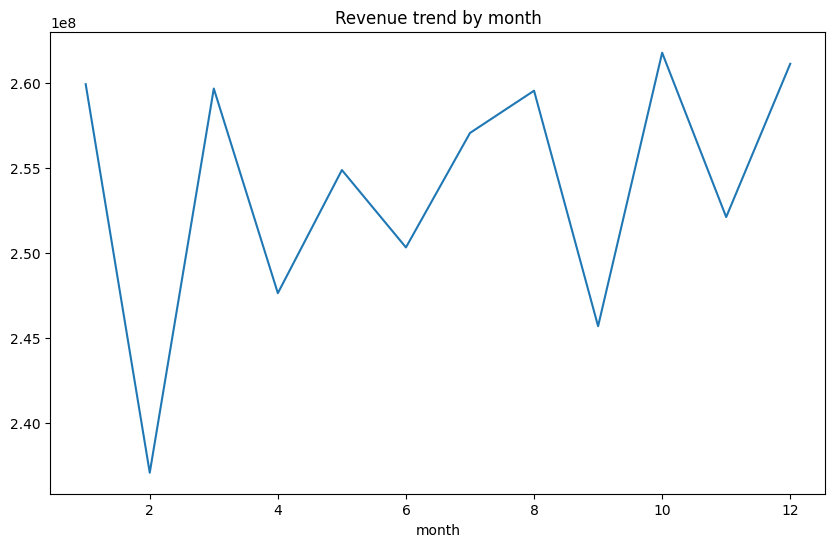

In [ ]:
#4. What Are the Monthly Sales Trends?
monthly_sales = amazon.groupby('month')['revenue'].sum()
monthly_sales.plot(figsize=(10,6))
plt.title('Revenue trend by month')
plt.show()


The line plot reveals highly volatile monthly sales that zig-zag throughout the year, crashing to an absolute low in February before recovering through sharp seasonal fluctuations to reach major revenue peaks in October and December.

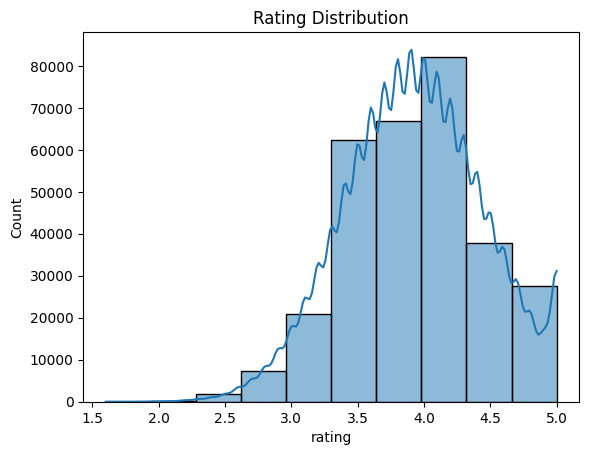

In [ ]:
#5. Rating Distribution
sns.histplot(amazon['rating'], bins=10, kde=True)
plt.title('Rating Distribution')
plt.show()

The rating distribution forms a clear bell-shaped curve that shifts toward higher values, proving that general customer satisfaction is strong with the vast majority of scores clustering between 3.3 and 4.3. The absolute highest concentration of feedback peaks between 4.0 and 4.3 with over 80,000 reviews, while poor ratings below 3.0 remain extremely rare.

In [ ]:
#6. Which Locations Generate the Most Revenue?
location=amazon.groupby('location')['revenue'].sum().sort_values(ascending=False)
location

,revenue
location,
Delhi,6.143930e+08
Mumbai,6.097774e+08
Bangalore,6.092891e+08
Hyderabad,6.076964e+08
Chennai,6.055588e+08


Delhi generates the highest revenue at roughly 614.39 million, closely followed by Mumbai 609.78 million) and Bangalore 609.29 million. However, the exceptionally narrow 1.4% gap between all five cities proves that purchasing power is perfectly balanced across India's major urban hubs rather than being concentrated in a single region.

In [ ]:
#7.Do Discounts Increase Revenue?
amazon[['discount','revenue']].corr()



,discount,revenue
discount,1.000000,-0.291042
revenue,-0.291042,1.000000


Discounts do not increase revenue; instead, there is a clear negative correlation of -0.291 between the two variables. This proves that as discount percentages go up, total revenue significantly decreases, meaning aggressive price cuts are actively hurting the business's bottom line rather than driving financial growth.

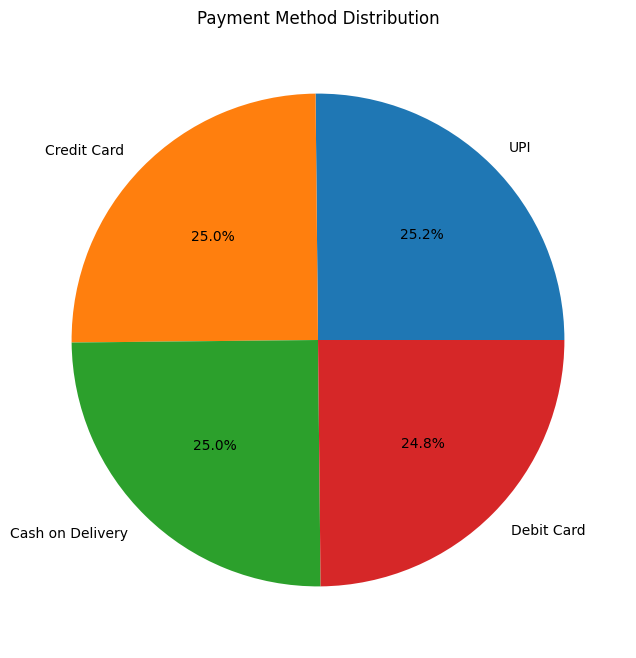

In [ ]:
#8. Payment Method Distribution
payment_counts = amazon['payment_method'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()

From the the pie chart reveals an almost perfectly equal split among customer payment preferences, led by UPI at 25.2%, followed by Credit Card (25.0%), Cash on Delivery (25.0%), and Debit Card (24.8%). This narrow 0.4% variance proves that the business must optimize and support all payment infrastructure channels equally, as no single method dominates consumer behavior.

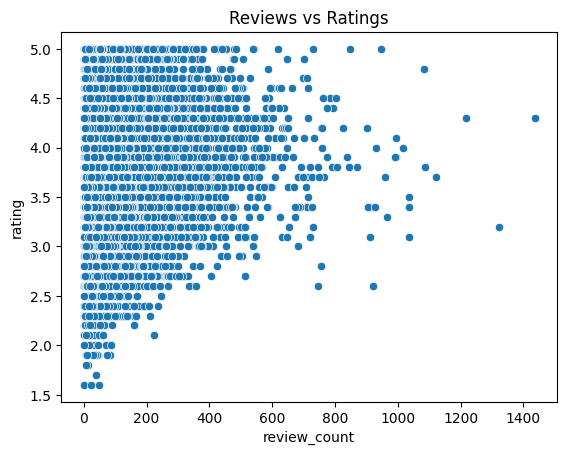

In [ ]:
#9. Reviews vs Ratings Relationship
sns.scatterplot(data=amazon, x='review_count', y='rating')
plt.title('Reviews vs Ratings')
plt.show()

The scatter plot reveals that as a product's review count increases past roughly 600, its ratings narrow dramatically and stabilize above 3.0, completely avoiding extremely low scores. This indicates that high-volume, highly popular items naturally converge toward consistent mid-to-high customer satisfaction, while lower-volume products suffer from intense rating volatility.

In [ ]:
#10. What Is the Overall Return Rate and Which Categories Have the Highest Returns?
return_rate = amazon['returned'].mean()*100
print(return_rate)

11.677159167598548


In [ ]:
amazon.groupby('category')['returned'].mean()*100

,returned
category,
Beauty,11.779908
Clothing,11.767594
Electronics,11.363488
Home,11.673749
Sports,11.800293


The platform's overall return rate sits at 11.68%, with Sports technically experiencing the highest individual return rate at 11.80%, followed closely by Beauty (11.78%) and Clothing (11.77%). However, because there is an exceptionally narrow 0.44% variance across all categories, this uniform distribution points to a systemic, platform-wide return issue rather than product deficiencies unique to any single category

In [ ]:
#11. Does Shipping Time Increase Returns?
amazon[['shipping_time_days','returned']].corr()

,shipping_time_days,returned
shipping_time_days,1.00000,0.05192
returned,0.05192,1.00000


In [ ]:
shipping = amazon.groupby('shipping_time_days')['returned'].mean()*100
print(shipping)

shipping_time_days
1    10.758365
2    10.689917
3    10.613161
4    10.662265
5    10.540945
6    20.936594
Name: returned, dtype: float64


Delivery times under 5 days maintain a stable return rate around 10.6%, but the moment a shipment takes 6 days or longer, the return rate drastically doubles to 20.94%. This sharp threshold indicates that while the overall correlation appears weak (0.05), hitting a 6-day delivery delay creates a critical bottleneck that severely triggers customer returns.

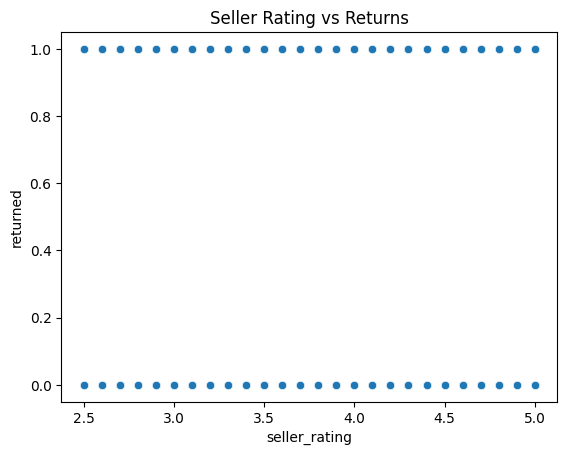

In [ ]:
#12. Seller Rating vs Returns
sns.scatterplot(data=amazon, x='seller_rating', y='returned')
plt.title('Seller Rating vs Returns')
plt.show()

The scatter plot shows an even distribution of data points across the entire 2.5 to 5.0 seller rating spectrum for both kept (0) and returned (1) items. This completely uniform distribution proves that a seller's rating has no impact or relationship on whether a product gets returned.

In [ ]:
#13. What Causes Revenue Leakage?
return_rate = amazon['returned'].mean()*100
print(return_rate)


11.677159167598548


In [ ]:
delivery_status = (amazon['delivery_status'].value_counts(normalize=True)*100)
print(delivery_status)

delivery_status
In Transit    29.481591
Delayed       29.459422
Delivered     29.381502
Returned      11.677159
In Tr          0.000326
Name: proportion, dtype: float64


In [ ]:
poor_sellers = (amazon.groupby('seller_id')['seller_rating'].mean().sort_values())
print(poor_sellers)

seller_id
S4899    3.220000
S1644    3.244828
S7537    3.290476
S9079    3.305714
S7787    3.322727
           ...   
S9804    4.183333
S3539    4.185714
S3774    4.214815
S9995    4.220000
S9256    4.289286
Name: seller_rating, Length: 9000, dtype: float64


Major revenue leakage stems from logistics inefficiencies, with 29.46% of shipments currently delayed and 11.68% resulting in costly returns. Furthermore, low-rated merchant accounts like S4899 (3.22 rating) and S1644 (3.24 rating) highlight underperforming sellers who likely drive poor customer experiences and exacerbate these losses.